In [1]:
import pandas as pd
df = pd.read_csv('datasets/train.csv')
print(df.shape)
print(df.head())
df.info()


(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
df['Age'] = df['Age'].fillna(df['Age'].median()) 

In [4]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 

In [5]:
df.drop('Cabin', axis = 1, inplace= True)

In [6]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [7]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [8]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

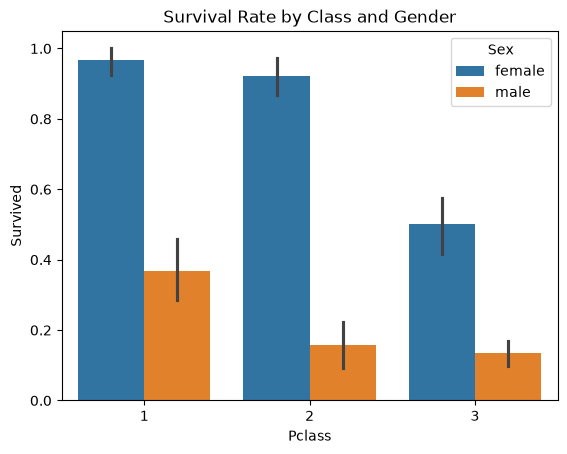

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title("Survival Rate by Class and Gender")
plt.show()

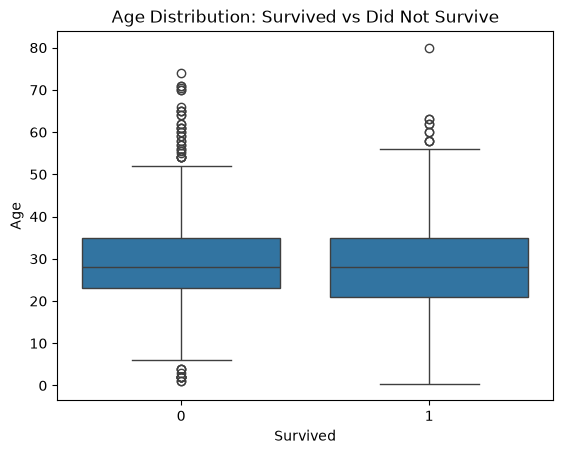

In [12]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution: Survived vs Did Not Survive")
plt.show()

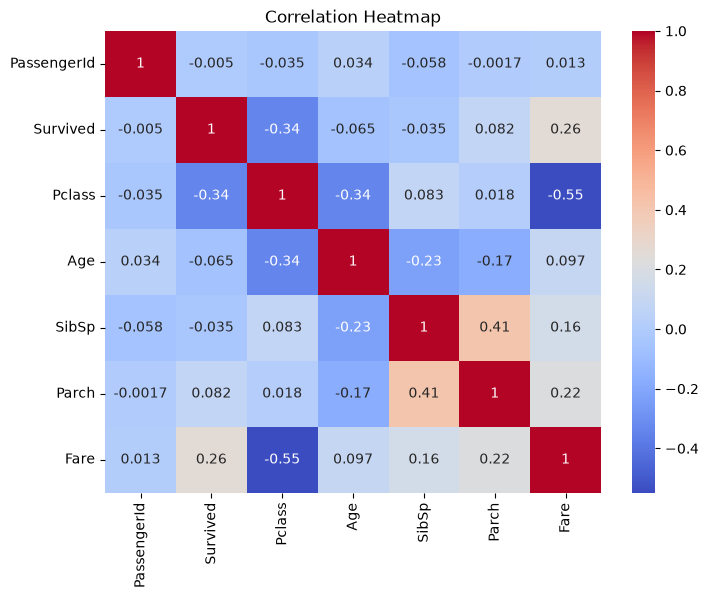

In [13]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

## Key Findings
- Gender was the strongest predictor of survival: women survived at 
  significantly higher rates than men across every passenger class
- Passenger class amplified this gap for men — 1st class men survived at 
  more than double the rate of 2nd/3rd class men, while women stayed 
  relatively high across all classes
- Age alone was a weak predictor (correlation: -0.065) — median age was 
  nearly identical between survivors and non-survivors, showing gender and 
  class mattered far more than age in isolation
- Fare (0.26) and Pclass (-0.34) both correlated with survival, and were 
  strongly correlated with each other (-0.55) — confirming that wealth/
  social status was a major factor in survival chances
- Families tended to travel together (SibSp-Parch correlation: 0.41), 
  though family size alone was a weaker predictor than gender or class